<a href="https://colab.research.google.com/github/iwatsuki-yuuki/Matsuo-GCI/blob/main/competition2%E6%8F%90%E5%87%BA%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [ベースライン] 第2回データ分析コンペティション：NFL Draft Prediction

　本ノートブックでは、「スポーツパフォーマンステストおよび選手情報をもとに、NFLドラフト指名の有無（Drafted）を予測する」タスクのベースラインモデルを構築します。



## 目次
1. セットアップ
2. データ読み込み
3. データの分析・EDA
4. 前処理
5. ベースラインモデル
6. 仮説と特徴量エンジニアリング
7. 提出ファイル作成
8. 今後の展望

## 1. セットアップ

In [1]:
# Google Driveのマウント（Colab上で自分のデータにアクセスするための設定です）
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# モジュールのインポート
import numpy as np  # 数値計算や配列操作を行うためのライブラリ
import pandas as pd  # 表形式のデータを扱うためのライブラリ
import matplotlib.pyplot as plt  # データ可視化のための基本的なグラフ描画ライブラリ
import seaborn as sns  # 高機能な統計グラフを描画するライブラリ
from sklearn.preprocessing import LabelEncoder  # カテゴリ変数を数値に変換するエンコーダ
from sklearn.ensemble import RandomForestClassifier  # ランダムフォレストによる分類器
from sklearn.model_selection import StratifiedKFold  # 層化K分割交差検証を行うクラス
from sklearn.metrics import roc_auc_score  # ROC AUCスコアを計算する評価指標

## 2. データ読み込み

In [3]:
PATH = '/content/drive/MyDrive/Colab Notebooks/GCI/competition_2/data/'

train = pd.read_csv(PATH + 'train.csv')  # 学習用データの読み込み
test = pd.read_csv(PATH + 'test.csv')    # テスト用データの読み込み

データのサイズを確認

In [4]:
print('Train:', train.shape)
print('Test:', test.shape)

Train: (2781, 16)
Test: (696, 15)


データの可視化

In [5]:
train.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


詳細な情報を確認

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   object 
 13  Position_Type     2781 non-null   object 
 14  Position          2781 non-null   object 
 15  Drafted           2781 non-null   float64
dtypes: float64(10), int64(2), object(4)
memory

## 3. データの分析・EDA

欠損値の確認

In [7]:
train.isnull().sum()

,0
Id,0
Year,0
Age,435
School,0
Height,0
Weight,0
Sprint_40yd,145
Vertical_Jump,554
Bench_Press_Reps,721
Broad_Jump,581


In [8]:
test.isnull().sum()

,0
Id,0
Year,0
Age,115
School,0
Height,0
Weight,0
Sprint_40yd,29
Vertical_Jump,143
Bench_Press_Reps,184
Broad_Jump,147


ドラフト選出された選手の数

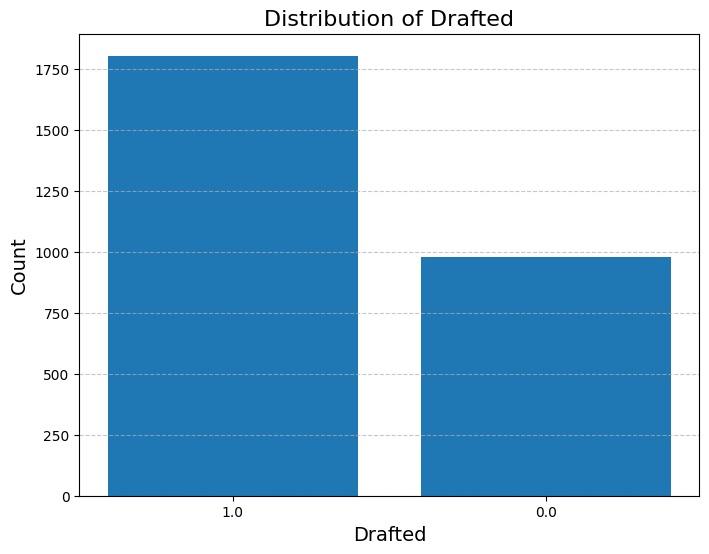

In [9]:
drafted_counts = train['Drafted'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(drafted_counts.index.astype(str), drafted_counts.values)
plt.title('Distribution of Drafted', fontsize=16)
plt.xlabel('Drafted', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

割合

In [10]:
drafted_percentage = train['Drafted'].value_counts(normalize=True) * 100

print(f"Percentage of 0: {drafted_percentage.get(0, 0):.2f}%")
print(f"Percentage of 1: {drafted_percentage.get(1, 0):.2f}%")

Percentage of 0: 35.17%
Percentage of 1: 64.83%


「Id」「Drafted」列を除く数値データについて可視化


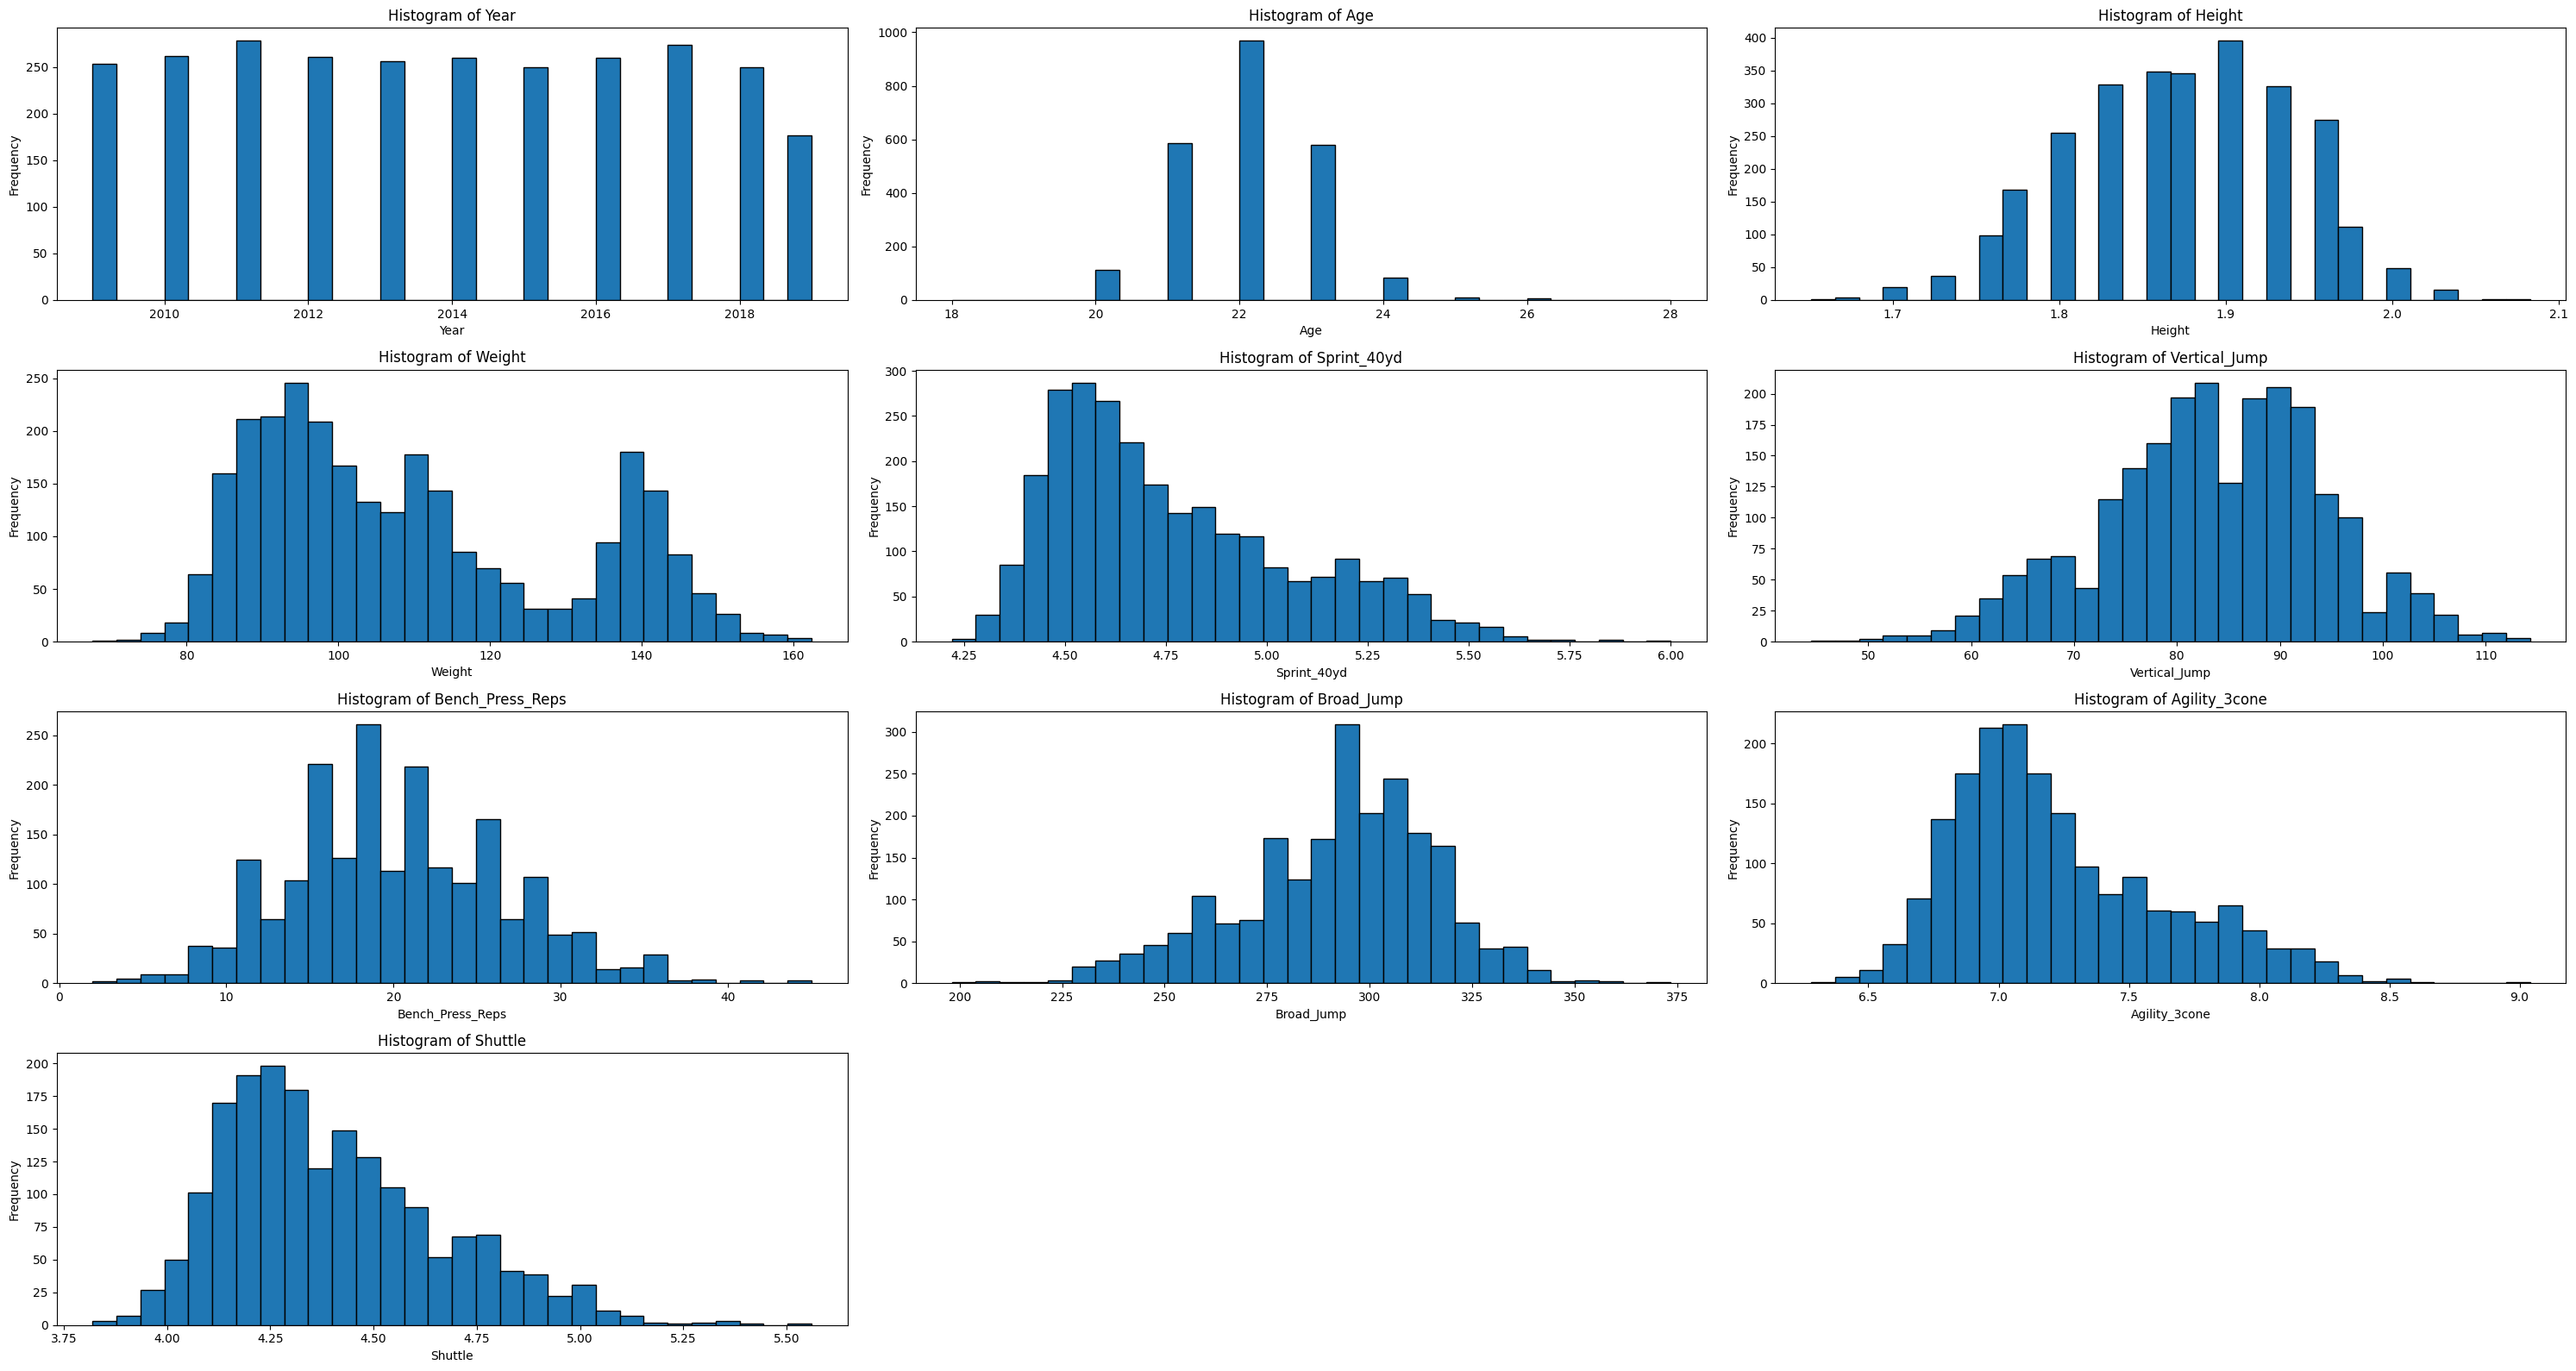

In [11]:
# 数値列だけを取り出す（Id, Drafted列は除く）
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['Id', 'Drafted'])

# プロット
num_cols = len(numeric_cols)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(10 * cols, 4 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(train[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [12]:
# カラム名の確認
numeric_cols

Index(['Year', 'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
       'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle'],
      dtype='object')

　数値データの相関行列をヒートマップで確認

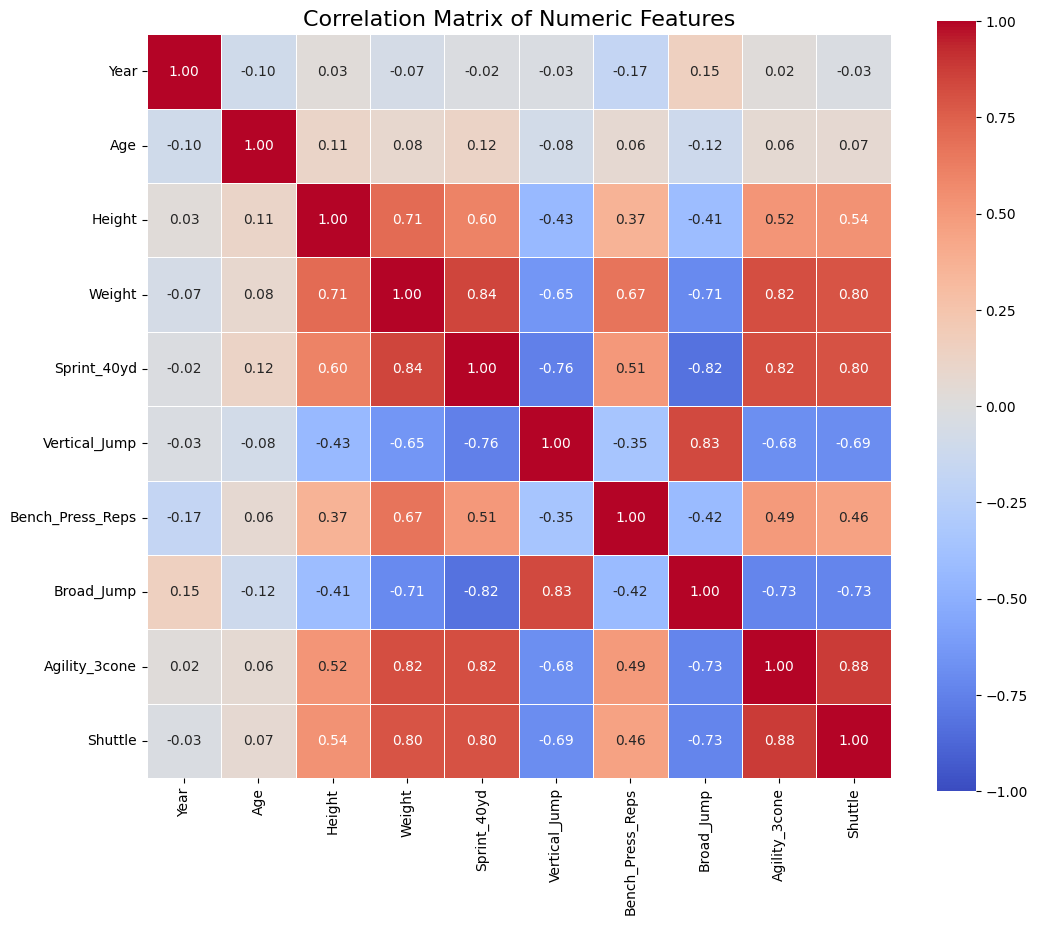

In [13]:
# 数値列だけを取り出す（Id, Drafted列は除く）
numeric_cols = train.select_dtypes(include=['number']).drop(['Id', 'Drafted'], axis=1)

# 相関行列を計算
corr_matrix = numeric_cols.corr()

# ヒートマップをプロット
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

カテゴリデータについて可視化

In [14]:
# カテゴリデータを抽出
categorical_cols = train.select_dtypes(include=['object', 'category']).columns

# 各列の水準数を取得（カテゴリの種類）
levels_count = {col: train[col].nunique() for col in categorical_cols}

for col, count in levels_count.items():
    print(f"{col}: {count} levels")


School: 236 levels
Player_Type: 3 levels
Position_Type: 7 levels
Position: 20 levels


　Schoolは水準数が236とかなり多い

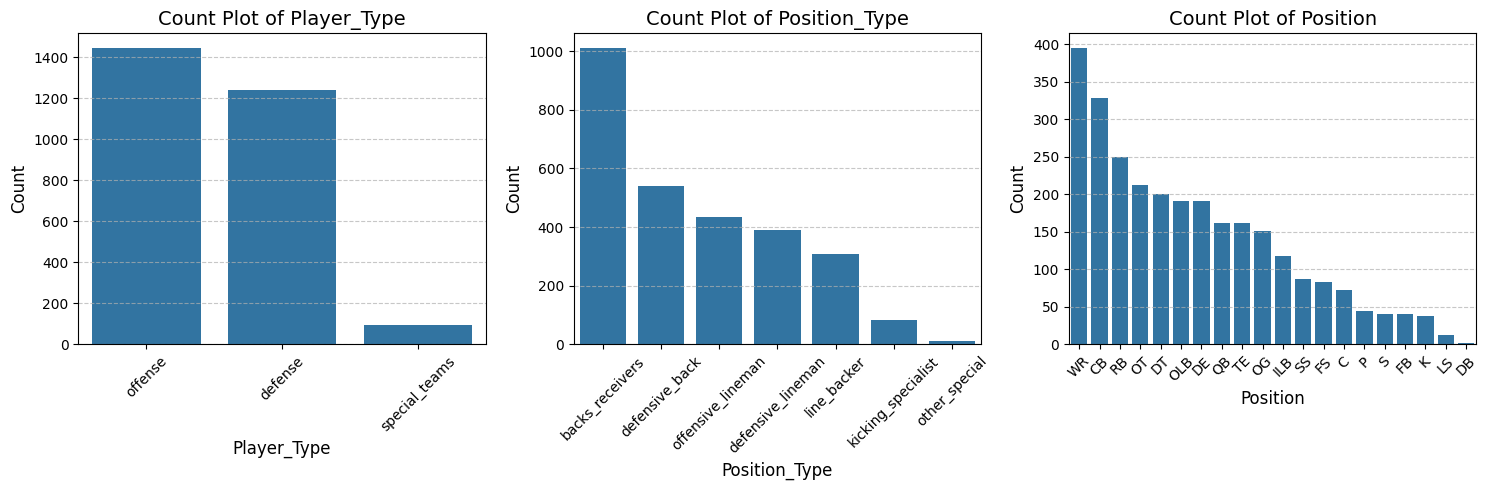

In [15]:
# カテゴリデータ（object型またはcategory型）を抽出し、School列を除外
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# グラフ描画準備
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 各カテゴリ変数でカウントプロット
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=train, order=train[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

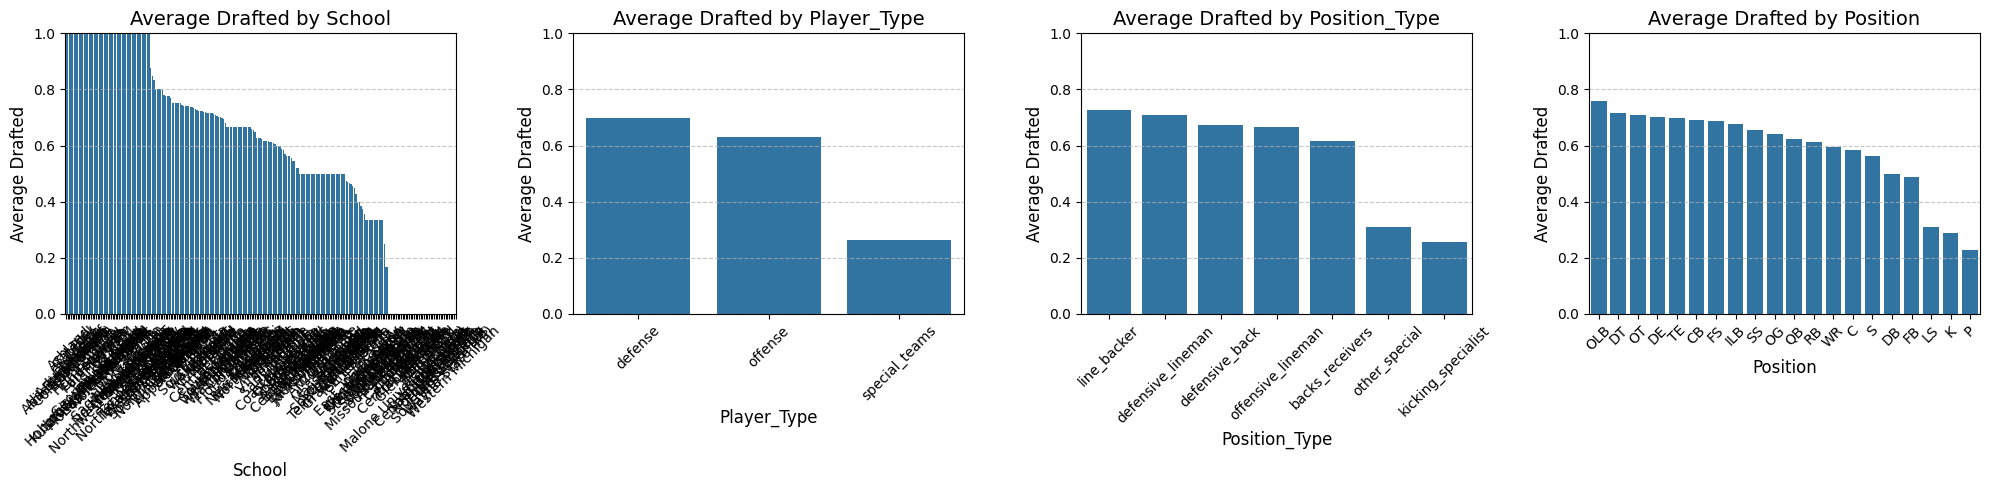

In [16]:
# カテゴリ変数（object型またはcategory型）を抽出
# schoolは潰れるけどどんな感じか見たいから省かない
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
#categorical_cols = categorical_cols.drop('School')

# グラフ描画準備
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 各カテゴリ変数ごとに Drafted 列の平均を棒グラフで描画
for i, col in enumerate(categorical_cols):
    mean_values = train.groupby(col)['Drafted'].mean().sort_values(ascending=False)
    sns.barplot(x=mean_values.index, y=mean_values.values, ax=axes[i])
    axes[i].set_title(f'Average Drafted by {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Average Drafted', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


schoolでdraftedの平均値が大きいものを抽出する（とりあえず0.7以上）

みた感じめちゃ重要っぽい

あとで特徴量の重要度を調べる段階で要確認

In [17]:
df_school = train.groupby('School')['Drafted'].mean().sort_values(ascending=False)
df_school[df_school > 0.7]

,Drafted
School,
Abilene Christian,1.000000
Ala-Birmingham,1.000000
Ashland,1.000000
Ark-Pine Bluff,1.000000
Concordia (MN),1.000000
...,...
Arizona,0.714286
Michigan,0.714286
Alabama,0.712329


## 4. 前処理

　欠損補完とエンコーディング


「Age」「Sprint_40yd」「Vertical_Jump」「Bench_Press_Reps」「Broad_Jump」「Agility_3cone」「Shuttle」列に欠損値がある。


ここでどのような値で欠損値を埋めた方がいいのか考える。

候補としては


1. 平均値
2. 中央値
3. 最頻値
4. 前後の値
5. 回帰補完（あとで調べる）

これらの候補があるけど、実際何を使うのか決める。

sprrint_40yardとageはあとで調べた感じめちゃくちゃ重要な特徴量なので慎重に選ぶ


計算量的な問題を含めてこの2つは1.2.3の全ての通りを試す

調べたら
ageはmean、sprintはmost_frequentがよかったからこれで補完する


データがバラバラだから4はやらない

In [18]:
train = train.drop(columns=["Id"])
test = test.drop(columns=["Id"])

In [19]:
# 補完する対象の列
cols_to_fill = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                'Broad_Jump', 'Agility_3cone', 'Shuttle']

# 平均値で補完する対象の列（'Vertical_Jump', 'Bench_Press_Reps','Broad_Jump', 'Agility_3cone', 'Shuttle）
cols_to_fill_mean = ['Vertical_Jump', 'Bench_Press_Reps','Broad_Jump', 'Agility_3cone', 'Shuttle']

# 平均値以外での補完方法を考える重要なカラム
cols_to_fill_flexible = ['Age', 'Sprint_40yd']

cols_to_fill_age = ['Age']
cols_to_fill_sprint = ['Sprint_40yd']

# train の平均で train/test 両方を補完
for col in cols_to_fill_mean:
    mean_value = train[col].mean()
    train[col] = train[col].fillna(mean_value)
    test[col] = test[col].fillna(mean_value)

'''
# 補完方法
strategies = ['mean', 'median', 'most_frequent']

# 平均値と中央値と最頻値でそれぞれのデータを補完してみて、一番精度が良さそうな組み合わせにする
# 多分パターンは3の2乗通りあると思う
# train の平均で train/test 両方を補完
for col in cols_to_fill_mean:
    mean_value = train[col].mean()
    train[col] = train[col].fillna(mean_value)
    test[col] = test[col].fillna(mean_value)

# 前通りいける補完ライブラリと欠損値を全部に適用できるライブラリ
from itertools import product
from sklearn.impute import SimpleImputer

# 補完パターン（3の2乗 = 9通り）
combinations = list(product(strategies, repeat=len(cols_to_fill_flexible)))

# 結果を保存する辞書
train_versions = {}
test_versions = {}

# 各パターンで補完
for i, (age_strat, sprint_strat) in enumerate(combinations, start=1):
    # deep copy
    train_copy = train.copy()
    test_copy = test.copy()

    # Age 補完（trainでfit → train/test両方にtransform）
    imputer_age = SimpleImputer(strategy=age_strat)
    imputer_age.fit(train[['Age']])
    train_copy[['Age']] = imputer_age.transform(train[['Age']])
    test_copy[['Age']] = imputer_age.transform(test[['Age']])

    # Sprint_40yd 補完
    imputer_sprint = SimpleImputer(strategy=sprint_strat)
    imputer_sprint.fit(train[['Sprint_40yd']])
    train_copy[['Sprint_40yd']] = imputer_sprint.transform(train[['Sprint_40yd']])
    test_copy[['Sprint_40yd']] = imputer_sprint.transform(test[['Sprint_40yd']])

    # 結果を保存（例：train_1, test_1, ..., train_9, test_9）
    train_versions[f'train_{i}'] = train_copy
    test_versions[f'test_{i}'] = test_copy
  '''

"\n# 補完方法\nstrategies = ['mean', 'median', 'most_frequent']\n\n# 平均値と中央値と最頻値でそれぞれのデータを補完してみて、一番精度が良さそうな組み合わせにする\n# 多分パターンは3の2乗通りあると思う\n# train の平均で train/test 両方を補完\nfor col in cols_to_fill_mean:\n    mean_value = train[col].mean()\n    train[col] = train[col].fillna(mean_value)\n    test[col] = test[col].fillna(mean_value)\n\n# 前通りいける補完ライブラリと欠損値を全部に適用できるライブラリ\nfrom itertools import product\nfrom sklearn.impute import SimpleImputer\n\n# 補完パターン（3の2乗 = 9通り）\ncombinations = list(product(strategies, repeat=len(cols_to_fill_flexible)))\n\n# 結果を保存する辞書\ntrain_versions = {}\ntest_versions = {}\n\n# 各パターンで補完\nfor i, (age_strat, sprint_strat) in enumerate(combinations, start=1):\n    # deep copy\n    train_copy = train.copy()\n    test_copy = test.copy()\n\n    # Age 補完（trainでfit → train/test両方にtransform）\n    imputer_age = SimpleImputer(strategy=age_strat)\n    imputer_age.fit(train[['Age']])\n    train_copy[['Age']] = imputer_age.transform(train[['Age']])\n    test_copy[['Age']] = imputer_age.

ageは平均値、sprintは最頻値で補完

In [20]:
for col in cols_to_fill_age:
    mean_value = train[col].mean()
    train[col] = train[col].fillna(mean_value)
    test[col] = test[col].fillna(mean_value)

for col in cols_to_fill_sprint:
    most_frequent_value = train[col].mode()[0]
    train[col] = train[col].fillna(most_frequent_value)
    test[col] = test[col].fillna(most_frequent_value)

うまく補完できているのか確認する

In [21]:
# train_versions['train_1'].isnull().sum()

　欠損値があるかを確認

In [22]:
train.isnull().sum()

,0
Year,0
Age,0
School,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0


In [23]:
test.isnull().sum()

,0
Year,0
Age,0
School,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0


これで、trainとtestの欠損値がなった

テストデータには含まれている学校名が訓練データにある場合エラーを吐いてきたので防ぐ（Originalエンコーダーを使用）

In [24]:
! pip install category_encoders

1.  ラベルエンコーディング
2.  onehotエンコーディング

試した結果1の方がよかった

多分大学名の数が多すぎた

In [25]:
# ラベルエンコーディング

from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# ラベルエンコーダを保持する辞書
label_encoders = {}

# エンコード対象のカテゴリ列
categorical_cols = ["School", "Player_Type", "Position_Type", "Position"]

for col in categorical_cols:
    # 欠損値を "unknown" に変換
    train[col] = train[col].fillna("unknown")
    test[col] = test[col].fillna("unknown")

    # エンコーダを作成して train のみで fit
    le = LabelEncoder()
    le.fit(train[col])

    # test に未知カテゴリがあれば "unknown" に置き換える
    known_classes = set(le.classes_)
    test[col] = test[col].apply(lambda x: x if x in known_classes else "unknown")

    # "unknown" が fit 時に含まれてなかったら追加
    if "unknown" not in le.classes_:
        le.classes_ = np.append(le.classes_, "unknown")

    # エンコードを実行
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])

    # 保存（必要ならあとで逆変換に使える）
    label_encoders[col] = le

In [26]:
print(train.dtypes)

Year                  int64
Age                 float64
School                int64
Height              float64
Weight              float64
Sprint_40yd         float64
Vertical_Jump       float64
Bench_Press_Reps    float64
Broad_Jump          float64
Agility_3cone       float64
Shuttle             float64
Player_Type           int64
Position_Type         int64
Position              int64
Drafted             float64
dtype: object


In [27]:
'''
# onehotエンコーディング
categorical_cols = ["School", "Player_Type", "Position_Type", "Position"]
train[categorical_cols] = train[categorical_cols].fillna("unknown")
test[categorical_cols] = test[categorical_cols].fillna("unknown")

# get_dummiesで明示的にエンコード
train = pd.get_dummies(train, columns=categorical_cols).astype(int)
test = pd.get_dummies(test, columns=categorical_cols).astype(int)

# trainとtestの列揃え（重要）
train, test = train.align(test, join="left", axis=1, fill_value=0)
'''

'\n# onehotエンコーディング\ncategorical_cols = ["School", "Player_Type", "Position_Type", "Position"]\ntrain[categorical_cols] = train[categorical_cols].fillna("unknown")\ntest[categorical_cols] = test[categorical_cols].fillna("unknown")\n\n# get_dummiesで明示的にエンコード\ntrain = pd.get_dummies(train, columns=categorical_cols).astype(int)\ntest = pd.get_dummies(test, columns=categorical_cols).astype(int)\n\n# trainとtestの列揃え（重要）\ntrain, test = train.align(test, join="left", axis=1, fill_value=0)\n'

うまく全てエンコーダできたか確認する

In [28]:
#print(train[categorical_cols].head())
#print(test[categorical_cols].head())

In [29]:
# print("School" in train.columns)  # Trueならまだエンコードされてない

In [30]:
train.head(10)

,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,2011,21.0,99,1.9050,140.160042,5.39,59.69,29.000000,251.46,7.910000,4.940000,1,5,10,1.0
1,2011,24.0,0,1.8288,87.089735,4.31,101.60,16.000000,332.74,7.230447,4.399422,1,0,19,1.0
2,2018,21.0,42,1.8542,92.986436,4.51,91.44,10.000000,309.88,6.950000,4.370000,1,0,19,1.0
3,2010,21.0,51,1.9304,148.778297,5.09,76.20,39.000000,254.00,8.120000,4.710000,0,2,4,1.0
4,2016,21.0,29,1.8796,92.079251,4.64,78.74,20.236408,281.94,7.130000,4.200000,1,0,19,1.0
5,2011,21.0,66,1.8542,112.490908,4.58,91.44,27.000000,289.56,6.880000,4.340000,0,4,11,1.0
6,2011,23.0,211,1.8288,89.357697,4.42,95.25,12.000000,312.42,6.870000,4.070000,0,1,1,1.0
7,2015,23.0,122,1.7526,89.811289,4.61,73.66,11.000000,276.86,7.230447,4.400000,1,0,15,1.0
8,2012,22.0,156,1.9558,143.788781,5.36,74.93,20.236408,259.08,7.810000,4.900000,1,5,10,0.0
9,2018,22.0,130,1.9304,138.799265,5.15,71.12,19.000000,269.24,7.870000,4.500000,1,5,10,1.0


正規化する

In [31]:
'''
# この正規化はしない方が精度がよかった
from sklearn.preprocessing import StandardScaler
features_to_scale = train.drop(columns=["Drafted"]).select_dtypes(include=["number"]).columns

scaler = StandardScaler()
train[features_to_scale] = scaler.fit_transform(train[features_to_scale])
'''

'\n# この正規化はしない方が精度がよかった\nfrom sklearn.preprocessing import StandardScaler\nfeatures_to_scale = train.drop(columns=["Drafted"]).select_dtypes(include=["number"]).columns\n\nscaler = StandardScaler()\ntrain[features_to_scale] = scaler.fit_transform(train[features_to_scale])\n'

## 5. ベースラインモデル

ベースラインモデル構築

ランダムフォレスト使用

交差検証方

データを7個に分けると精度がよかった（それ以上増やすと精度が落ちる）

第9回の講義で講師が多くても最大8個って言ってた

あとSchoolない方が全然いいわ

In [32]:
# 特徴量と目的変数に分ける
X = train.drop(columns=["Drafted",'School'])
y = train["Drafted"]

# モデルとCVの設定
model = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    random_state=2025
)

# 分割数を7にした（ハイパラ調整）
skf = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

# スコア格納用
auc_scores = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # 予測とスコアリング
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Fold 1
  AUC: 0.8035
Fold 2
  AUC: 0.826
Fold 3
  AUC: 0.8543
Fold 4
  AUC: 0.8529
Fold 5
  AUC: 0.7861
Fold 6
  AUC: 0.7875
Fold 7
  AUC: 0.8498

Average Validation AUC: 0.8229


ベストなハイパラをグリッドリサーチで探す

なんかここで得られたハイパラは謎にイマイチだった

In [33]:
'''
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, make_scorer

# 特徴量と目的変数
X = train.drop(columns=["Drafted"])
y = train["Drafted"]

# モデル
model = RandomForestClassifier(random_state=2025)

# グリッドサーチのハイパーパラメータ候補
param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [3, 5, 10],
}

# AUC をスコアに使う
auc_scorer = make_scorer(roc_auc_score, needs_proba=True)

# Stratified K-Fold
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

# グリッドサーチの実行
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=auc_scorer,
    cv=cv,
    n_jobs=-1,  # 並列実行（CPUが複数なら高速）
    verbose=1
)

grid.fit(X, y)

# 結果表示
print("ベストスコア（AUC）:", round(grid.best_score_, 4))
print("ベストパラメータ:", grid.best_params_)
'''

'\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.model_selection import GridSearchCV, StratifiedKFold\nfrom sklearn.metrics import roc_auc_score, make_scorer\n\n# 特徴量と目的変数\nX = train.drop(columns=["Drafted"])\ny = train["Drafted"]\n\n# モデル\nmodel = RandomForestClassifier(random_state=2025)\n\n# グリッドサーチのハイパーパラメータ候補\nparam_grid = {\n    "n_estimators": [100, 150, 200],\n    "max_depth": [3, 5, 10],\n}\n\n# AUC をスコアに使う\nauc_scorer = make_scorer(roc_auc_score, needs_proba=True)\n\n# Stratified K-Fold\ncv = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)\n\n# グリッドサーチの実行\ngrid = GridSearchCV(\n    estimator=model,\n    param_grid=param_grid,\n    scoring=auc_scorer,\n    cv=cv,\n    n_jobs=-1,  # 並列実行（CPUが複数なら高速）\n    verbose=1\n)\n\ngrid.fit(X, y)\n\n# 結果表示\nprint("ベストスコア（AUC）:", round(grid.best_score_, 4))\nprint("ベストパラメータ:", grid.best_params_)\n'

決定木以外に回帰モデルを実装してみた（精度イマイチ）

In [34]:
'''
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 特徴量と目的変数に分ける
X = train.drop(columns=["Drafted"])
y = train["Drafted"]

# ここのmodelを変更しただけ（収束しなかったから正規化してる）
# pipelineは正規化とモデルの学習を一気にやってるだけ
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# 分割数を7にした（ハイパラ調整）
skf = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

# スコア格納用
auc_scores = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # 予測とスコアリング
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))
'''

'\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.pipeline import make_pipeline\n\n# 特徴量と目的変数に分ける\nX = train.drop(columns=["Drafted"])\ny = train["Drafted"]\n\n# ここのmodelを変更しただけ（収束しなかったから正規化してる）\n# pipelineは正規化とモデルの学習を一気にやってるだけ\nmodel = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))\n\n# 分割数を7にした（ハイパラ調整）\nskf = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)\n\n# スコア格納用\nauc_scores = []\n\n# Stratified K-Fold による学習と評価\nfor fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):\n    print(f"Fold {fold + 1}")\n\n    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]\n    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]\n\n    # モデル学習\n    model.fit(X_train, y_train)\n\n    # 予測とスコアリング\n    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]\n    auc = roc_auc_scor

勾配ブースティング実装してみた（精度イマイチ）

In [35]:
'''
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# スコア格納用
auc_scores = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # 予測とスコアリング
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))
'''

'\nfrom xgboost import XGBClassifier\nfrom sklearn.model_selection import StratifiedKFold\n\nmodel = XGBClassifier(use_label_encoder=False, eval_metric=\'logloss\', random_state=42)\nskf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)\n\n# スコア格納用\nauc_scores = []\n\n# Stratified K-Fold による学習と評価\nfor fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):\n    print(f"Fold {fold + 1}")\n\n    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]\n    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]\n\n    # モデル学習\n    model.fit(X_train, y_train)\n\n    # 予測とスコアリング\n    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]\n    auc = roc_auc_score(y_valid, y_valid_pred_proba)\n    auc_scores.append(auc)\n    print(f"  AUC: {round(auc, 4)}")\n\n# 平均AUCを表示\nmean_auc = np.mean(auc_scores)\nprint("\nAverage Validation AUC:", round(mean_auc, 4))\n'

以下はどの組み合わせが最適か確かめるために使用した


正直全部平均値でよかった

労力に合ってない


In [36]:
'''
from sklearn.preprocessing import LabelEncoder

# 対象のカテゴリ列
categorical_cols = ["Player_Type", "Position_Type", "Position"]

# 各 train_1～9 に対してラベルエンコードを適用
for i in range(1, 10):
    df = train_versions[f"train_{i}"].copy()

    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

    train_versions[f"train_{i}"] = df
'''

'\nfrom sklearn.preprocessing import LabelEncoder\n\n# 対象のカテゴリ列\ncategorical_cols = ["Player_Type", "Position_Type", "Position"]\n\n# 各 train_1～9 に対してラベルエンコードを適用\nfor i in range(1, 10):\n    df = train_versions[f"train_{i}"].copy()\n\n    for col in categorical_cols:\n        le = LabelEncoder()\n        df[col] = le.fit_transform(df[col].astype(str))\n\n    train_versions[f"train_{i}"] = df\n'

In [37]:
'''
# 各補完パターンのラベル（optional）
strategies = ['mean', 'median', 'most_frequent']
from itertools import product
combos = list(product(strategies, repeat=2))

results = []

# train_1 ～ train_9 に対して評価
for i in range(1, 10):
    train_df = train_versions[f"train_{i}"]

    X = train_df.drop(columns=["Drafted", "School"])
    y = train_df["Drafted"]

    model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=2025)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    auc_scores = []
    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
        auc = roc_auc_score(y_valid, y_valid_pred_proba)
        auc_scores.append(auc)

    mean_auc = np.mean(auc_scores)

    results.append({
        "train_version": f"train_{i}",
        "Age_strategy": combos[i-1][0],
        "Sprint_40yd_strategy": combos[i-1][1],
        "mean_auc": mean_auc
    })

# 結果をDataFrameに
results_df = pd.DataFrame(results).sort_values(by="mean_auc", ascending=False)
print("\n=== AUC Ranking ===")
print(results_df)
'''

'\n# 各補完パターンのラベル（optional）\nstrategies = [\'mean\', \'median\', \'most_frequent\']\nfrom itertools import product\ncombos = list(product(strategies, repeat=2))\n\nresults = []\n\n# train_1 ～ train_9 に対して評価\nfor i in range(1, 10):\n    train_df = train_versions[f"train_{i}"]\n\n    X = train_df.drop(columns=["Drafted", "School"])\n    y = train_df["Drafted"]\n\n    model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=2025)\n    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\n\n    auc_scores = []\n    for train_idx, valid_idx in skf.split(X, y):\n        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]\n        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]\n\n        model.fit(X_train, y_train)\n        y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]\n        auc = roc_auc_score(y_valid, y_valid_pred_proba)\n        auc_scores.append(auc)\n\n    mean_auc = np.mean(auc_scores)\n\n    results.append({\n        "train_version

## 6. 仮説と特徴量エンジニアリング

特徴量エンジニアリング

BMI求めたけど精度が変わらなかった

他にもいろいろデータを弄り回して有用なデータを作り出すべき（未実装）

例えばtotaljumpとか（多分意味ない）

もっと知識をもとに特徴量を作成した方がいいかも？？

LLMを活用してどんなんがいいか聞いてみるのはあり（ネットでちょっと調べたけどいい記事なかった）

LLMに聞いてみた！

Power_Index...
Bench_Press_Reps * Weight
(筋力と体重の複合指標)


Speed_BMI...
Sprint_40yd / BMI
(体格あたりのスピード)


Height_to_Weight...
Height / Weight
(体型のバランス)



全部目的変数に追加したら下がっとるやんけ！！！！


目的変数むしろ減らした方がいいのかも

In [38]:
'''
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)
    df['Power_index'] = df['Bench_Press_Reps'] * df['Weight']
    df['Speed_BMI'] = df['Sprint_40yd'] / df['BMI']
    df['Height_to_Weight'] = df['Height'] / df['Weight']
'''

"\nfor df in [train, test]:\n    df['BMI'] = df['Weight'] / (df['Height'] ** 2)\n    df['Power_index'] = df['Bench_Press_Reps'] * df['Weight']\n    df['Speed_BMI'] = df['Sprint_40yd'] / df['BMI']\n    df['Height_to_Weight'] = df['Height'] / df['Weight']\n"

In [40]:
train.head()

,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,2011,21.0,99,1.9050,140.160042,5.39,59.69,29.000000,251.46,7.910000,4.940000,1,5,10,1.0
1,2011,24.0,0,1.8288,87.089735,4.31,101.60,16.000000,332.74,7.230447,4.399422,1,0,19,1.0
2,2018,21.0,42,1.8542,92.986436,4.51,91.44,10.000000,309.88,6.950000,4.370000,1,0,19,1.0
3,2010,21.0,51,1.9304,148.778297,5.09,76.20,39.000000,254.00,8.120000,4.710000,0,2,4,1.0
4,2016,21.0,29,1.8796,92.079251,4.64,78.74,20.236408,281.94,7.130000,4.200000,1,0,19,1.0


In [ ]:
'''# 特徴量と目的変数に分ける
X = train.drop(columns=["Drafted"])
y = train["Drafted"]

# モデルとCVの設定
model = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    random_state=2025
)

# 分割数を7にした（ハイパラ調整）
skf = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

# スコア格納用
auc_scores = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # 予測とスコアリング
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))
'''

In [41]:
# 特徴量と目的変数に分ける
X = train.drop(columns=["Drafted","School"])
y = train["Drafted"]

test.drop(columns=["School"], inplace=True)

# モデルとCVの設定
model = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    random_state=2025
)

# 分割数を7にした（ハイパラ調整）
skf = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

# スコア・予測格納用
auc_scores = []
test_pred_proba_list = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # バリデーション予測 & スコア
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

    # テストデータ予測を保存
    test_pred_proba = model.predict_proba(test)[:, 1]
    test_pred_proba_list.append(test_pred_proba)

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

# テスト予測の平均を計算
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

Fold 1
  AUC: 0.8035
Fold 2
  AUC: 0.826
Fold 3
  AUC: 0.8543
Fold 4
  AUC: 0.8529
Fold 5
  AUC: 0.7861
Fold 6
  AUC: 0.7875
Fold 7
  AUC: 0.8498

Average Validation AUC: 0.8229


特徴量重要度を可視化

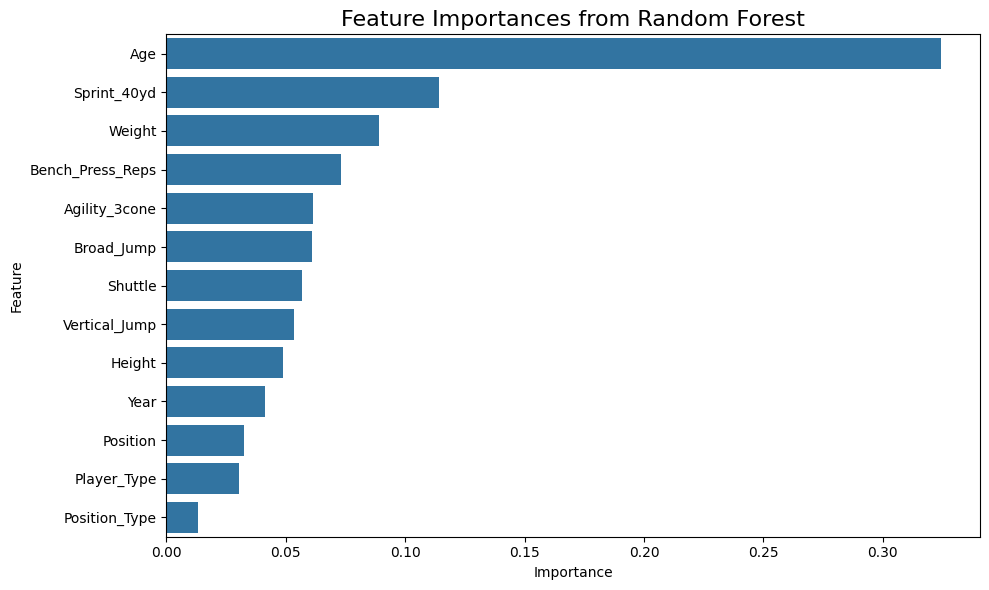

In [42]:
# 特徴量とその重要度をDataFrameにまとめる
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 可視化
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title('Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. 提出ファイル作成

In [57]:
# このセルを実行すると提出用のCSVファイルが作成されます
submission = pd.read_csv(PATH + 'sample_submission.csv') # PATHは必要に応じて変更の必要があります
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH + 'submission_com2.csv', index=False)